In [5]:
import sys
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path


def process_csv(path: Path) -> pl.DataFrame:
    df = pl.read_csv(path)
    df.columns = [
        "page_number",
        "uncompressed_size",
        "compressed_size",
        "compression_time",
        "decompression_time"]
    
    test, compressor = path.stem.split("_")
    df = df.with_columns(alg = pl.lit(compressor))
    df = df.with_columns(test = pl.lit(test))

    return df


In [6]:
compressors = ["lz4", "WKdm", "zlib", "WK64", "lzo", "zstd"]
dfs = []
for c in compressors:
    dfs.append(process_csv(Path(f"../data/llvm_{c}.csv")))

df3 = pl.concat(dfs)
curr_df = df3

Text(0.5, 1.05, 'Compressed size in B vs. frequency; LLVM build page images')

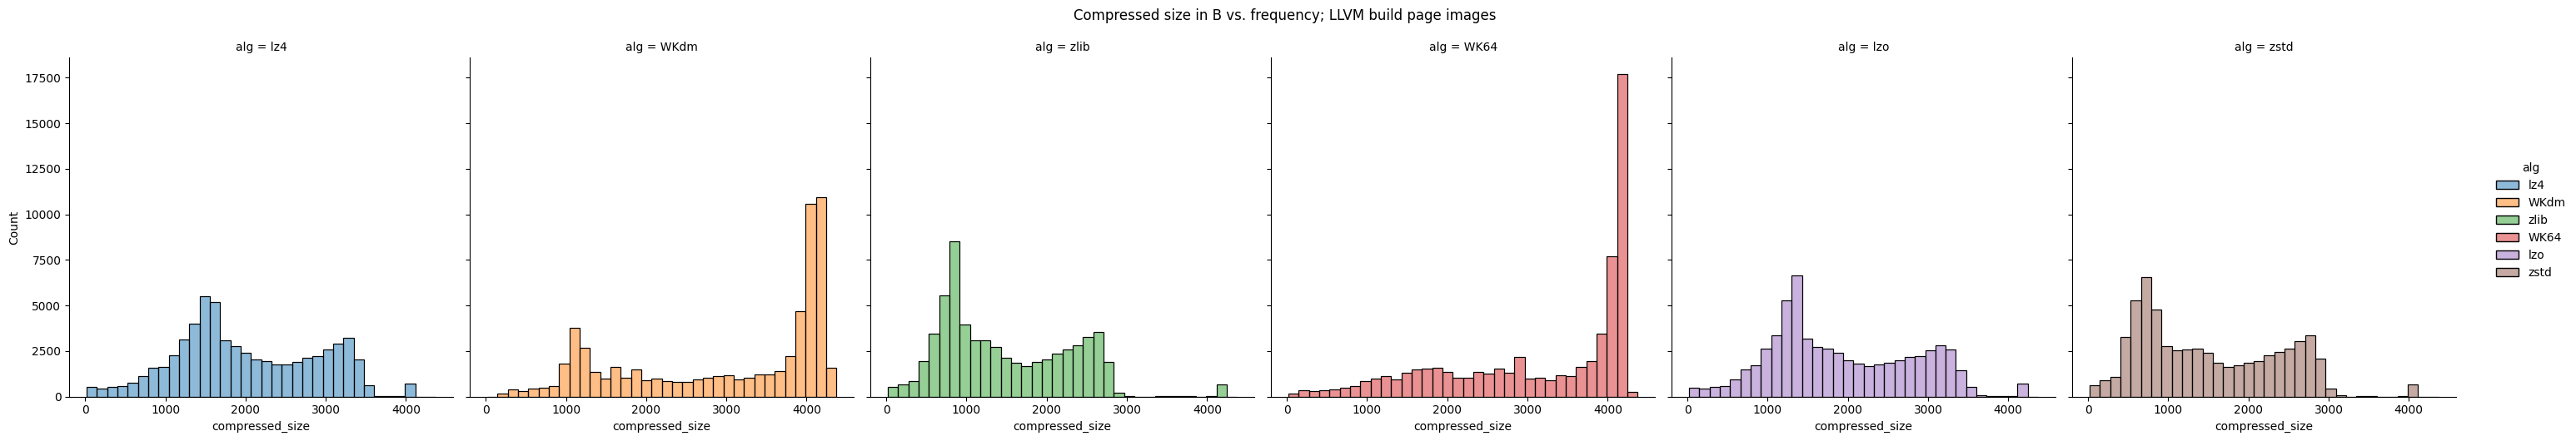

In [ ]:
g = sns.displot(
    data=curr_df, 
    x="compressed_size", 
    binwidth=128, 
    hue="alg",
    col="alg")
g.fig.suptitle("Compressed size in B vs. frequency; LLVM build page images", y=1.05)

Text(0.5, 1.05, 'Compressed size (B) vs. kde density; LLVM build page images')

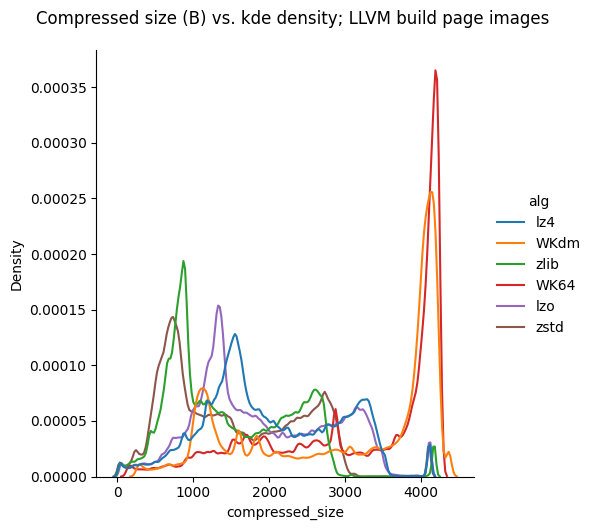

In [8]:
g = sns.displot(
    curr_df, 
    x="compressed_size", 
    hue="alg",
    kind="kde",
    bw_adjust=.25)
g.fig.suptitle("Compressed size (B) vs. kde density; LLVM build page images", y=1.05)

Text(0.5, 0.98, 'log(compression time) vs log(decompression time)')

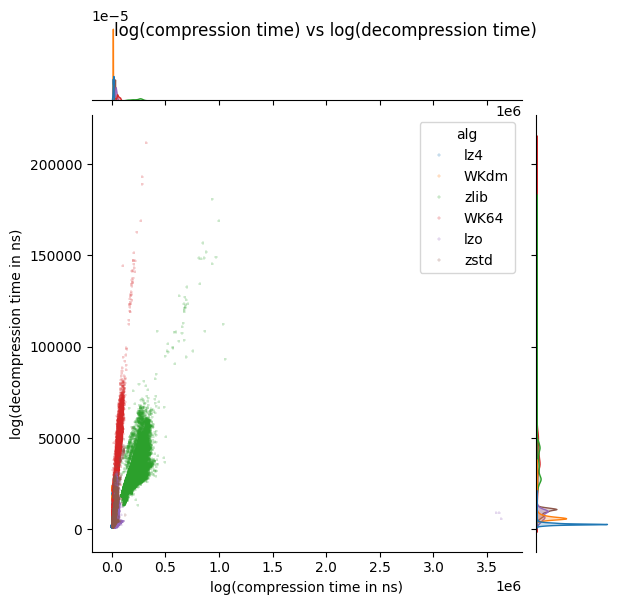

In [11]:
g = sns.jointplot(
    data=curr_df,
    x="compression_time",
    y="decompression_time",
    hue="alg",
    marker="+",
    s=5
)
g.set_axis_labels("log(compression time in ns)", "log(decompression time in ns)")
g.fig.suptitle("log(compression time) vs log(decompression time)")

Text(0.5, 0.98, 'log(compression time) vs log(decompression time); LLVM build page images')

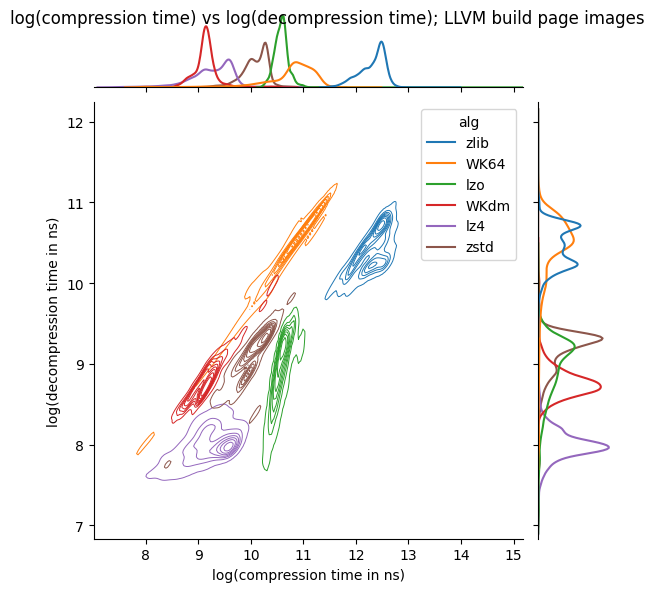

In [9]:
g = sns.jointplot(
    data=(curr_df
          #.filter(pl.col("alg").is_in(["lz4", "zlib"]))
          .with_columns(
        pl.col("compression_time").log().alias("log_compression_time"),
        pl.col("decompression_time").log().alias("log_decompression_time"))
          .sample(fraction=0.2)),  # sampling for speed
    x="log_compression_time",
    y="log_decompression_time",
    hue="alg",
    kind="kde",
    joint_kws={"gridsize" : 120, "linewidths": 0.7}  # lower grid size increases speed
)
g.set_axis_labels("log(compression time in ns)", "log(decompression time in ns)")
g.fig.suptitle("log(compression time) vs log(decompression time); LLVM build page images")

Text(0.5, 1.05, 'combined time vs. frequency; LLVM build page images')

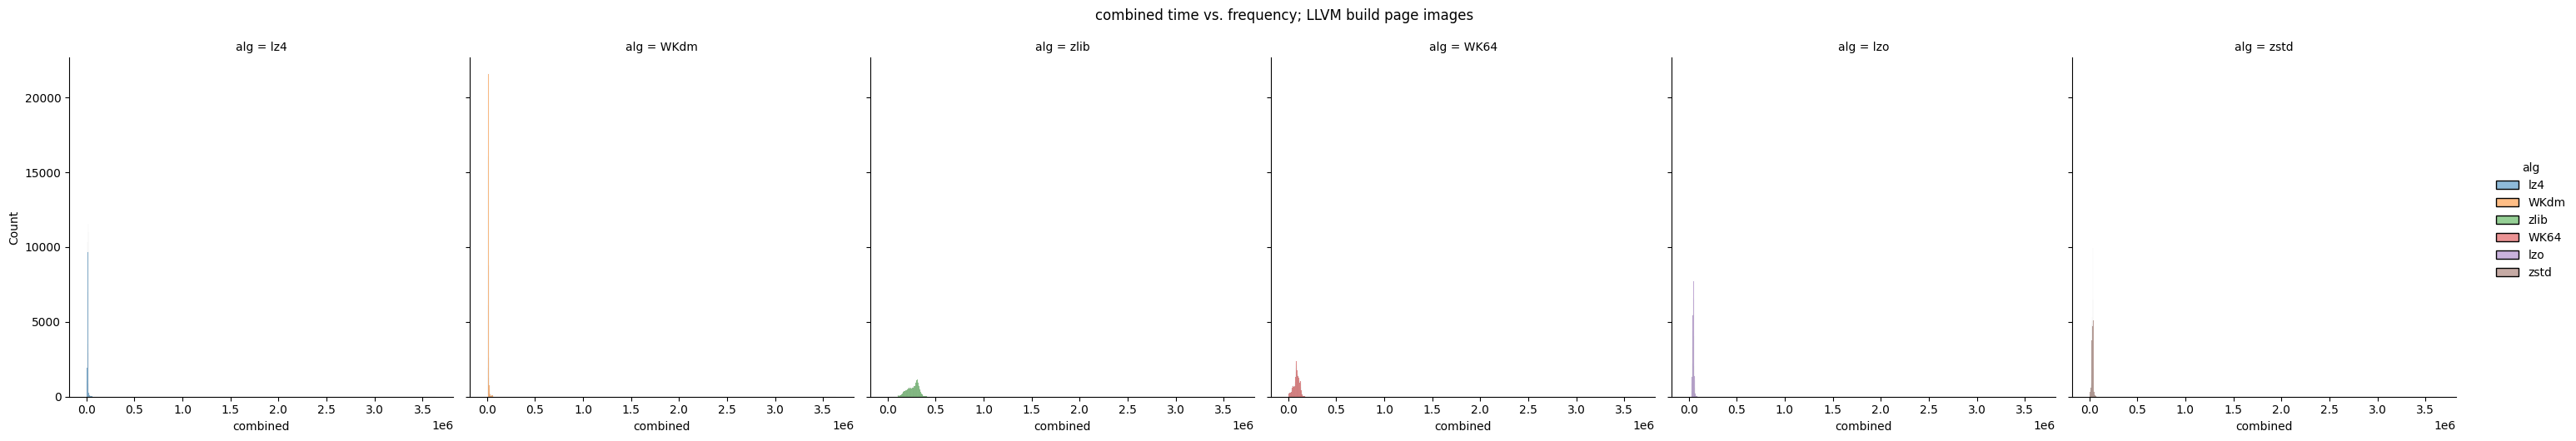

In [13]:
g = sns.displot(
    data=curr_df.with_columns(
        (pl.col("compression_time") + pl.col("decompression_time")).alias("combined")
    ), 
    x="combined", 
    hue="alg",
    col="alg")
g.fig.suptitle("combined time vs. frequency; LLVM build page images", y=1.05)

Text(0.5, 1.05, 'combined time vs. frequency; LLVM build page images')

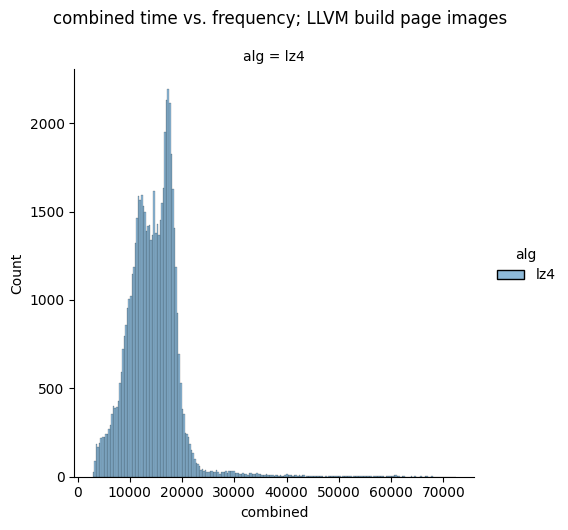

In [16]:
g = sns.displot(
    data=curr_df.filter(pl.col("alg").is_in(["lz4"])).with_columns(
        (pl.col("compression_time") + pl.col("decompression_time")).alias("combined")
    ), 
    x="combined", 
    hue="alg",
    col="alg")
g.fig.suptitle("combined time vs. frequency; LLVM build page images", y=1.05)